In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np

In [2]:
def girvan_newman_analysis(G, target_communities=2):
    results = {
        'removed_edges': [],
        'modularity_at_each_step': [],
        'num_components': [],
        'final_communities': None,
        'critical_edge': None,
        'max_modularity': -1,
        'optimal_step': 0
    }
    G_copy = G.copy()
    while G_copy.number_of_edges() > 0:
        betweenness = nx.edge_betweenness_centrality(G_copy)
        max_edge = max(betweenness, key=betweenness.get)
        max_betweenness = betweenness[max_edge]
        results['removed_edges'].append((max_edge[0], max_edge[1], max_betweenness))
        G_copy.remove_edge(*max_edge)
        components = list(nx.connected_components(G_copy))
        num_comp = len(components)
        results['num_components'].append(num_comp)
        if num_comp >= 2:
            communities = [set(c) for c in components]
            modularity = calculate_modularity(G, communities)
            results['modularity_at_each_step'].append(modularity)
            if modularity > results['max_modularity']:
                results['max_modularity'] = modularity
                results['optimal_step'] = len(results['removed_edges'])
                results['final_communities'] = communities
            if results['critical_edge'] is None:
                results['critical_edge'] = max_edge
        else:
            results['modularity_at_each_step'].append(0.0)
        if num_comp >= target_communities and len(components[0]) < G.number_of_nodes() / 2:
            break
    return results

In [3]:
def calculate_modularity(G, communities):
    m = G.number_of_edges()
    if m == 0:
        return 0.0
    node_to_community = {}
    for idx, comm in enumerate(communities):
        for node in comm:
            node_to_community[node] = idx
    Q = 0.0
    for u in G.nodes():
        for v in G.nodes():
            if u in node_to_community and v in node_to_community:
                A_uv = 1 if G.has_edge(u, v) else 0
                k_u = G.degree(u)
                k_v = G.degree(v)
                if node_to_community[u] == node_to_community[v]:
                    Q += A_uv - (k_u * k_v) / (2 * m)
    Q = Q / (2 * m)
    return Q

In [4]:
def visualize_results(G, results, true_labels):
    fig = plt.figure(figsize=(20, 12))
    ax1 = plt.subplot(2, 3, 1)
    steps = range(1, len(results['modularity_at_each_step']) + 1)
    ax1.plot(steps, results['modularity_at_each_step'], 'b-', linewidth=2)
    ax1.axvline(x=results['optimal_step'], color='r', linestyle='--', linewidth=2)
    ax1.set_xlabel('Edges Removed')
    ax1.set_ylabel('Modularity Q')
    ax1.set_title('Modularity Progression')
    ax1.grid(True, alpha=0.3)
    ax2 = plt.subplot(2, 3, 2)
    ax2.plot(steps, results['num_components'], 'g-', linewidth=2)
    ax2.set_xlabel('Edges Removed')
    ax2.set_ylabel('Number of Components')
    ax2.set_title('Network Fragmentation')
    ax2.grid(True, alpha=0.3)
    ax3 = plt.subplot(2, 3, 3)
    pos = nx.spring_layout(G, seed=42)
    true_colors = ['red' if true_labels[node] == 'Mr. Hi' else 'blue' for node in G.nodes()]
    nx.draw_networkx(G, pos, node_color=true_colors, node_size=500, with_labels=True, font_size=8, ax=ax3)
    ax3.set_title('Ground Truth Labels')
    ax3.axis('off')
    ax4 = plt.subplot(2, 3, 4)
    if results['final_communities']:
        detected_colors = []
        for node in G.nodes():
            if node in results['final_communities'][0]:
                detected_colors.append('orange')
            else:
                detected_colors.append('purple')
        nx.draw_networkx(G, pos, node_color=detected_colors, node_size=500, with_labels=True, font_size=8, ax=ax4)
    ax4.set_title('Detected Communities')
    ax4.axis('off')
    ax5 = plt.subplot(2, 3, 5)
    y_true = [0 if true_labels[node] == 'Mr. Hi' else 1 for node in sorted(G.nodes())]
    y_pred = [0 if node in results['final_communities'][0] else 1 for node in sorted(G.nodes())]
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax5)
    ax5.set_xlabel('Predicted')
    ax5.set_ylabel('True')
    ax5.set_title('Confusion Matrix')
    ax6 = plt.subplot(2, 3, 6)
    edge_labels = [f"Edge {i+1}" for i in range(min(10, len(results['removed_edges'])))]
    betweenness_values = [e[2] for e in results['removed_edges'][:10]]
    ax6.barh(edge_labels, betweenness_values)
    ax6.set_xlabel('Edge Betweenness')
    ax6.set_title('Top 10 Removed Edges')
    plt.tight_layout()
    plt.savefig('figures/q4_girvan_newman_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

In [5]:
def calculate_accuracy(detected_communities, true_labels):
    nodes = list(true_labels.keys())
    y_true = [0 if true_labels[node] == 'Mr. Hi' else 1 for node in nodes]
    y_pred1 = [0 if node in detected_communities[0] else 1 for node in nodes]
    y_pred2 = [1 if node in detected_communities[0] else 0 for node in nodes]
    acc1 = accuracy_score(y_true, y_pred1)
    acc2 = accuracy_score(y_true, y_pred2)
    return max(acc1, acc2)

OPERATION: CHAIN BREAKER
Target Network: Zachary's Karate Club
Nodes: 34
Edges: 78

OPERATION RESULTS
Total edges removed: 11
Maximum Modularity: 0.3600
Optimal step: 11
Critical Edge: (2, 13)
Final community sizes: [15, 19]
Accuracy vs Ground Truth: 94.12%


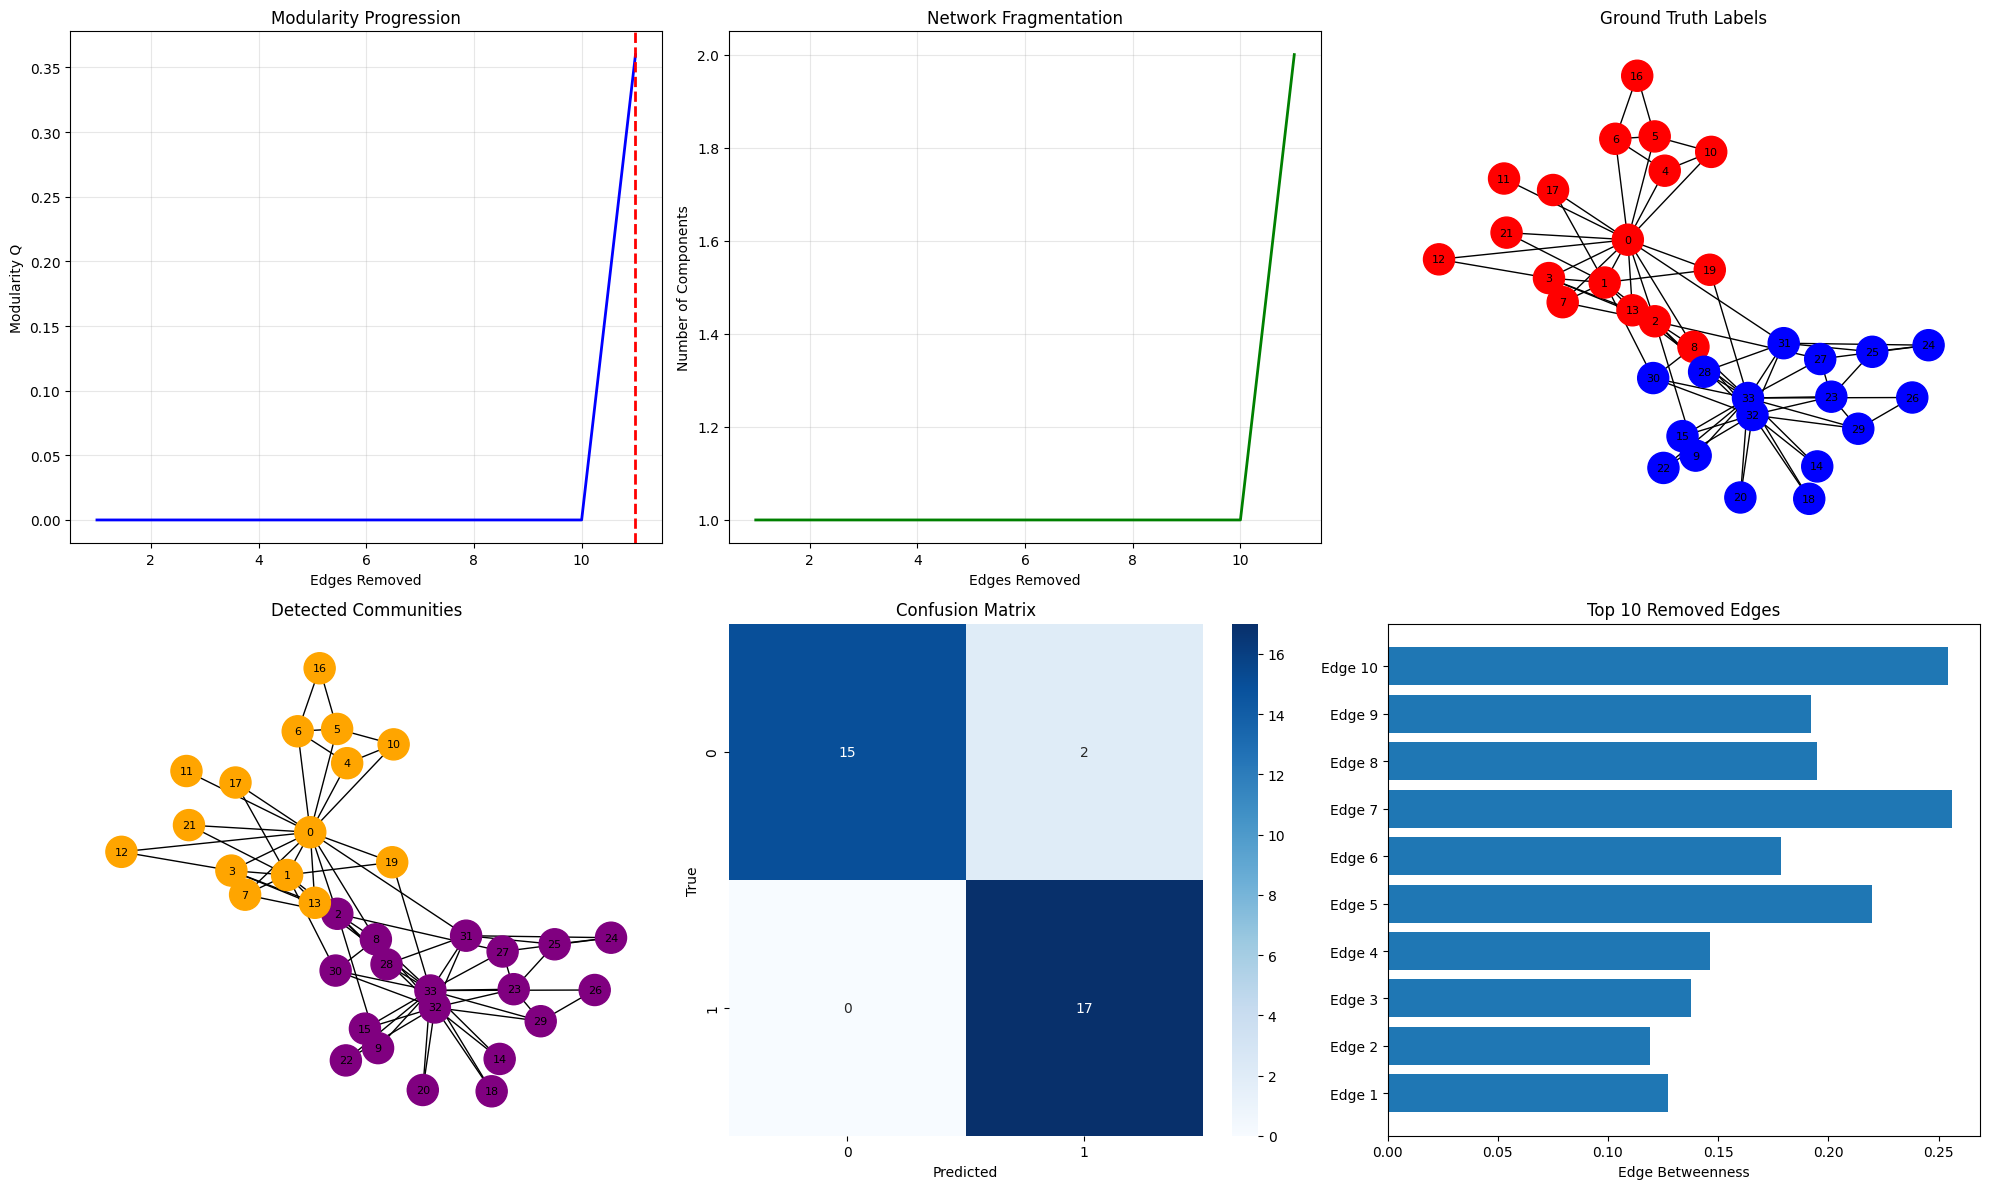

In [7]:

G = nx.karate_club_graph()
true_labels = {node: G.nodes[node]['club'] for node in G.nodes()}
print("=" * 60)
print("OPERATION: CHAIN BREAKER")
print("=" * 60)
print(f"Target Network: Zachary's Karate Club")
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
results = girvan_newman_analysis(G, target_communities=2)
print("\n" + "=" * 60)
print("OPERATION RESULTS")
print("=" * 60)
print(f"Total edges removed: {len(results['removed_edges'])}")
print(f"Maximum Modularity: {results['max_modularity']:.4f}")
print(f"Optimal step: {results['optimal_step']}")
print(f"Critical Edge: {results['critical_edge']}")
print(f"Final community sizes: {[len(c) for c in results['final_communities']]}")
accuracy = calculate_accuracy(results['final_communities'], true_labels)
print(f"Accuracy vs Ground Truth: {accuracy:.2%}")
visualize_results(G, results, true_labels)